# 02 · Preliminary predictive analysis

How much activity signal is in each single metric, and in a simple combined model, on the folded subset? This is a look at signal content, not the paper method (no Boltz-2 fine-tuning here).

> Preliminary. These use the ~20k compounds co-folded so far (a partial, roughly CID-ordered — hence roughly random — sample of the 49,985-compound library). Absolute numbers will shift as folding completes, and none of this includes fine-tuning yet, so nothing here speaks to the paper head-FT claim. What it does show: whether the co-folding is healthy, and whether the structural-confidence signals carry any activity information.

In [1]:
import os, sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160, "display.max_columns", 40)
ROOT = Path("/global/scratch/users/sergiomar10/boltzaff")
QC = pd.read_csv(ROOT / "results/runs/588689/qc.csv")
# all text black, normal weight (no bold)
BLK="#000000"; GRID="#dedede"
PALETTE=["#2a78d6","#eb6834","#1baf7a","#eda100","#e87ba4","#4a3aa7","#e34948","#008300"]
ACTIVE="#1baf7a"; INACTIVE="#9aa0a6"; BLUE="#2a78d6"
mpl.rcParams.update({
  "figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
  "text.color":BLK,"axes.labelcolor":BLK,"axes.titlecolor":BLK,"xtick.color":BLK,"ytick.color":BLK,
  "axes.edgecolor":BLK,"font.size":10,"font.weight":"normal","axes.titleweight":"normal","axes.labelweight":"normal",
  "axes.grid":True,"grid.color":GRID,"grid.linewidth":0.6,"axes.axisbelow":True,
  "axes.spines.top":False,"axes.spines.right":False,"figure.dpi":100})
METRICS=["confidence","complex_plddt","ptm","iptm","ligand_iptm","complex_pde"]
print(f"folded compounds: {len(QC)}   actives: {int(QC.Active.sum())} ({QC.Active.mean()*100:.2f}%)")


folded compounds: 21061   actives: 238 (1.13%)


In [2]:
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
y=QC.Active.values
feats=["score_boltz2"]+METRICS
D=QC[feats+["Active"]].dropna(); y=D.Active.values

## Single-metric ranking power
AUROC and average precision when ranking by each metric alone (pde is inverted: lower is better).

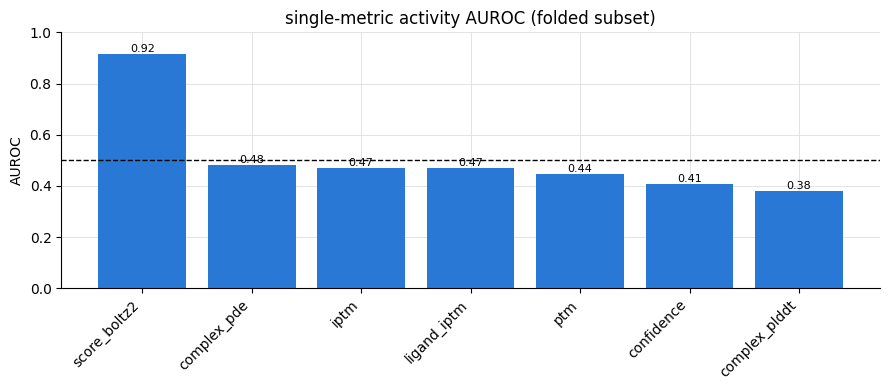

,metric,auroc,ap
0,score_boltz2,0.915,0.160
6,complex_pde,0.482,0.012
4,iptm,0.470,0.011
5,ligand_iptm,0.470,0.011
3,ptm,0.445,0.011
1,confidence,0.408,0.010
2,complex_plddt,0.380,0.009


In [3]:
rows=[]
for m in feats:
    s=D[m].values.astype(float)
    if m=="complex_pde": s=-s
    rows.append(dict(metric=m, auroc=roc_auc_score(y,s), ap=average_precision_score(y,s)))
res=pd.DataFrame(rows).sort_values("auroc",ascending=False)
fig,ax=plt.subplots(figsize=(9,4))
ax.bar(range(len(res)),res.auroc,color=BLUE)
ax.axhline(0.5,color=BLK,ls="--",lw=1)
ax.set_xticks(range(len(res))); ax.set_xticklabels(res.metric,rotation=45,ha="right")
ax.set_ylim(0,1); ax.set_ylabel("AUROC"); ax.set_title("single-metric activity AUROC (folded subset)")
for i,v in enumerate(res.auroc): ax.text(i,v,f"{v:.2f}",ha="center",va="bottom",fontsize=8)
plt.tight_layout(); plt.show()
res.round(3)

## Combined logistic-regression model (5-fold CV)
Activity regressed on the confidence metrics (out-of-fold predictions), vs the cached score alone.

confidence-features model : AUROC 0.618  AP 0.023
cached score_boltz2 alone  : AUROC 0.915  AP 0.160


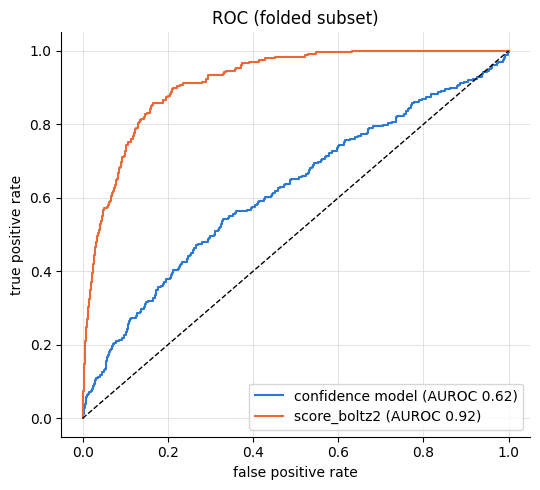

In [4]:
X=D[METRICS].values
clf=make_pipeline(StandardScaler(),LogisticRegression(max_iter=1000,class_weight="balanced"))
p_oof=cross_val_predict(clf,X,y,cv=5,method="predict_proba")[:,1]
print(f"confidence-features model : AUROC {roc_auc_score(y,p_oof):.3f}  AP {average_precision_score(y,p_oof):.3f}")
s=D.score_boltz2.values
print(f"cached score_boltz2 alone  : AUROC {roc_auc_score(y,s):.3f}  AP {average_precision_score(y,s):.3f}")
fig,ax=plt.subplots(figsize=(5.5,5))
for lab,sc,c in [("confidence model",p_oof,BLUE),("score_boltz2",s,PALETTE[1])]:
    fpr,tpr,_=roc_curve(y,sc); ax.plot(fpr,tpr,color=c,label=f"{lab} (AUROC {roc_auc_score(y,sc):.2f})")
ax.plot([0,1],[0,1],ls="--",color=BLK,lw=1)
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate"); ax.set_title("ROC (folded subset)")
ax.legend(); plt.tight_layout(); plt.show()